In [1]:
! pip install pandas numpy seaborn matplotlib


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

File naming convention

Each of the 7356 RAVDESS files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 02-01-06-01-02-01-12.mp4). These identifiers define the stimulus characteristics: 

Filename identifiers 

Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
Vocal channel (01 = speech, 02 = song).
Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
Repetition (01 = 1st repetition, 02 = 2nd repetition).
Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: 02-01-06-01-02-01-12.mp4 

Video-only (02)
Speech (01)
Fearful (06)
Normal intensity (01)
Statement "dogs" (02)
1st Repetition (01)
12th Actor (12)
Female, as the actor ID number is even.


In [3]:
import os
import csv

# Define the emotion code to label mapping
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Update this to your local dataset folder
dataset_path = "/Users/upendrasuryajonnalagadda/mindseye/Audio_Speech_Actors_01-24"
output_csv = "ravdess_full_metadata.csv"

# Collect (filepath, modality, channel, emotion, intensity, statement, repetition, actor, gender)
data = []

for actor_folder in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor_folder)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file[:-4].split("-")  # remove .wav extension
                if len(parts) == 7:
                    modality = parts[0]
                    channel = parts[1]
                    emotion_code = parts[2]
                    intensity = parts[3]
                    statement = parts[4]
                    repetition = parts[5]
                    actor = parts[6]

                    emotion = emotion_map.get(emotion_code, "unknown")
                    gender = "male" if int(actor) % 2 != 0 else "female"
                    file_path = os.path.join(actor_path, file)

                    data.append([
                        file_path, modality, channel, emotion, emotion_code,
                        intensity, statement, repetition, actor, gender
                    ])

# Write data to CSV
with open(output_csv, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        "file_path", "modality", "vocal_channel", "emotion", "emotion_code",
        "intensity", "statement", "repetition", "actor", "gender"
    ])
    writer.writerows(data)

print(f"✅ CSV generated successfully: {output_csv}")
print(f"📊 Total audio files processed: {len(data)}")

✅ CSV generated successfully: ravdess_full_metadata.csv
📊 Total audio files processed: 1440


In [4]:
df=pd.read_csv("ravdess_full_metadata.csv")
df.head()

,file_path,modality,vocal_channel,emotion,emotion_code,intensity,statement,repetition,actor,gender
0,/Users/upendrasuryajonnalagadda/mindseye/Audio...,3,1,angry,5,1,2,1,16,female
1,/Users/upendrasuryajonnalagadda/mindseye/Audio...,3,1,fearful,6,1,2,2,16,female
2,/Users/upendrasuryajonnalagadda/mindseye/Audio...,3,1,fearful,6,2,1,2,16,female
3,/Users/upendrasuryajonnalagadda/mindseye/Audio...,3,1,angry,5,2,1,1,16,female
4,/Users/upendrasuryajonnalagadda/mindseye/Audio...,3,1,disgust,7,1,1,1,16,female


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_path      1440 non-null   object
 1   modality       1440 non-null   int64 
 2   vocal_channel  1440 non-null   int64 
 3   emotion        1440 non-null   object
 4   emotion_code   1440 non-null   int64 
 5   intensity      1440 non-null   int64 
 6   statement      1440 non-null   int64 
 7   repetition     1440 non-null   int64 
 8   actor          1440 non-null   int64 
 9   gender         1440 non-null   object
dtypes: int64(7), object(3)
memory usage: 112.6+ KB


In [6]:
gender_map = {
    'male': 0,
    'female': 1,
    'Other': 2
}

df['gender_code']=df['gender'].map(gender_map)

In [7]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

               modality  vocal_channel  emotion_code     intensity  \
modality            NaN            NaN           NaN           NaN   
vocal_channel       NaN            NaN           NaN           NaN   
emotion_code        NaN            NaN  1.000000e+00  1.147079e-01   
intensity           NaN            NaN  1.147079e-01  1.000000e+00   
statement           NaN            NaN  4.829759e-18 -2.545584e-18   
repetition          NaN            NaN -1.697260e-17 -2.107015e-17   
actor               NaN            NaN  4.637065e-16  1.790043e-16   
gender_code         NaN            NaN  9.012867e-17  2.205715e-16   

                  statement    repetition         actor   gender_code  
modality                NaN           NaN           NaN           NaN  
vocal_channel           NaN           NaN           NaN           NaN  
emotion_code   4.829759e-18 -1.697260e-17  4.637065e-16  9.012867e-17  
intensity     -2.545584e-18 -2.107015e-17  1.790043e-16  2.205715e-16  
statement

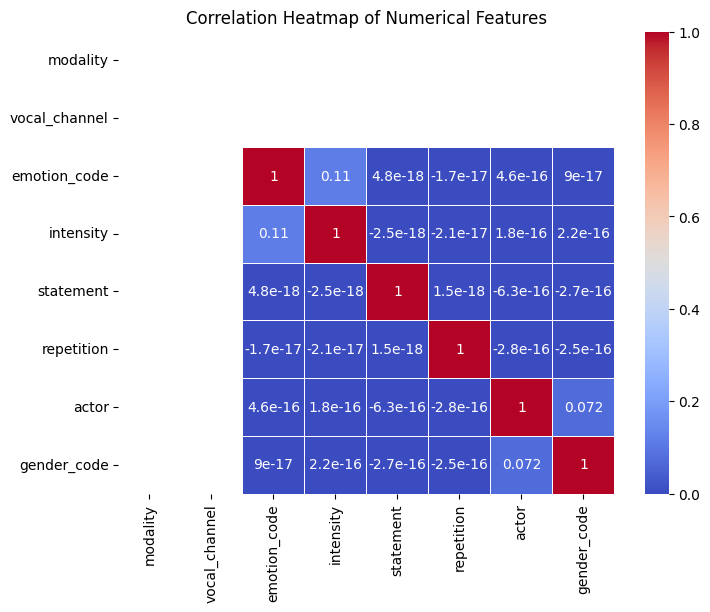

In [8]:
corr_matrix = numeric_df.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

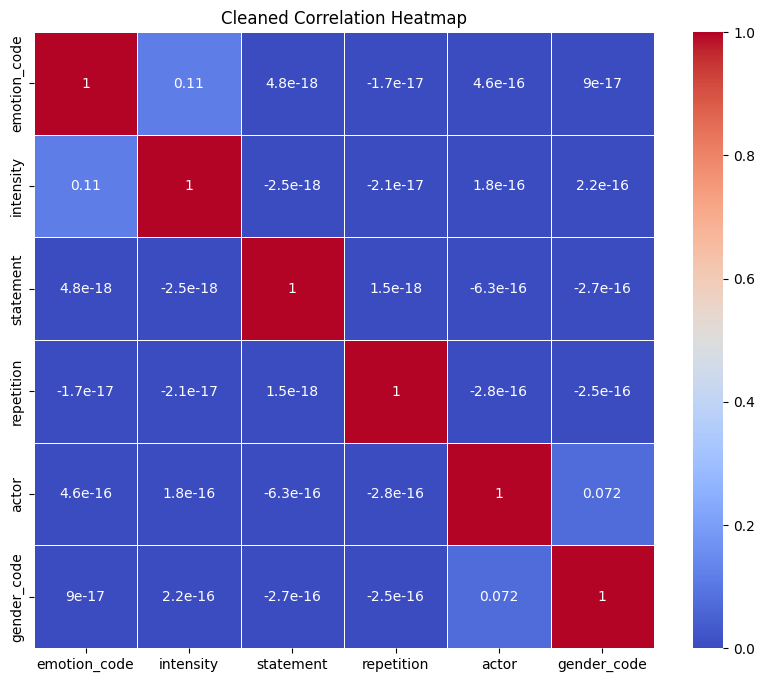

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is `df`
# Step 1: Keep only numeric columns
numeric_df = df.select_dtypes(include='number')

# Step 2: Compute correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Drop rows and columns that are all NaN
corr_matrix = corr_matrix.dropna(how='all').dropna(axis=1, how='all')

# Step 4: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Cleaned Correlation Heatmap")
plt.show()

In [10]:
! pip install scikit_learn 


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [11]:
from sklearn import svm


In [12]:
X=df[['gender_code','intensity']].values
y=df['emotion_code'].values

clf=svm.SVC(kernel='linear')
clf.fit(X,y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Plotting SVM decision boundary...


Text(0, 0.5, 'intensity')

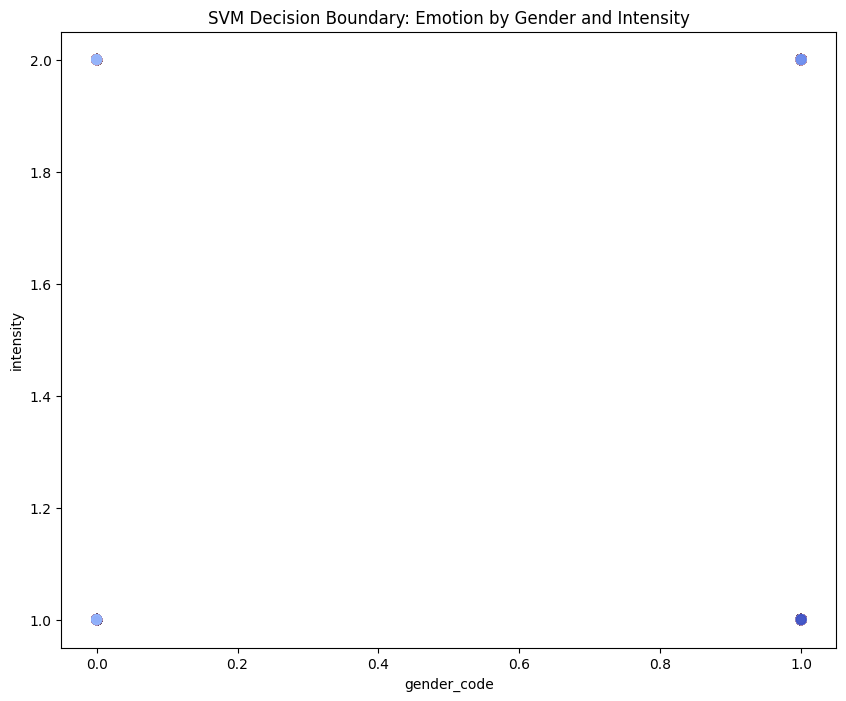

In [13]:
print("Plotting SVM decision boundary...")
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, alpha=0.8)
ax.set_title('SVM Decision Boundary: Emotion by Gender and Intensity')
ax.set_xlabel('gender_code')
ax.set_ylabel('intensity')

In [14]:
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, alpha=0.8)
ax.set_title('SVM Decision Boundary: Emotion by Gender and Intensity')
ax.set_xlabel('gender_code')
ax.set_ylabel('intensity')

Text(24.000000000000007, 0.5, 'intensity')

Plotting SVM decision boundary...


ValueError: cannot reshape array of size 20000 into shape (50,50)

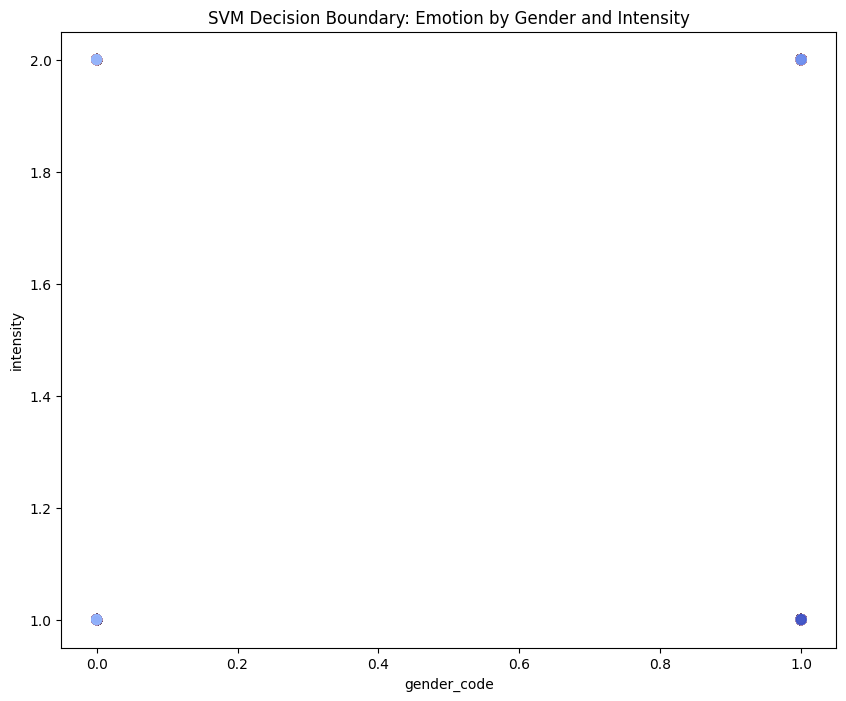

In [15]:



# --- 2. Prepare Features (X) and Target (y) ---
# This is your code! We use .values to get a NumPy array, which is good practice.
X = df[['gender_code', 'intensity']].values
y = df['emotion_code'].values


# --- 3. Create and Train the SVM Model ---
# This is also your code.
clf = svm.SVC(kernel='linear')
clf.fit(X, y)


# --- 4. Visualization ---
print("Plotting SVM decision boundary...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the data points, colored by their class (emotion_code)
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, alpha=0.8)
ax.set_title('SVM Decision Boundary: Emotion by Gender and Intensity')
ax.set_xlabel('gender_code')
ax.set_ylabel('intensity')

# --- Plot the decision boundary and margins ---
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the model on
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the decision function for each point on the grid
# Note: This works for binary and multi-class scenarios
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot the decision boundary and margins
# For multi-class, this will plot the boundaries for the one-vs-one classifiers.
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Highlight the support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')

# Add a legend for the classes and support vectors
legend_classes = ax.legend(*scatter.legend_elements(), title="Emotions")
ax.add_artist(legend_classes)
plt.legend(loc='upper left')

plt.show()



Plotting SVM decision boundary...


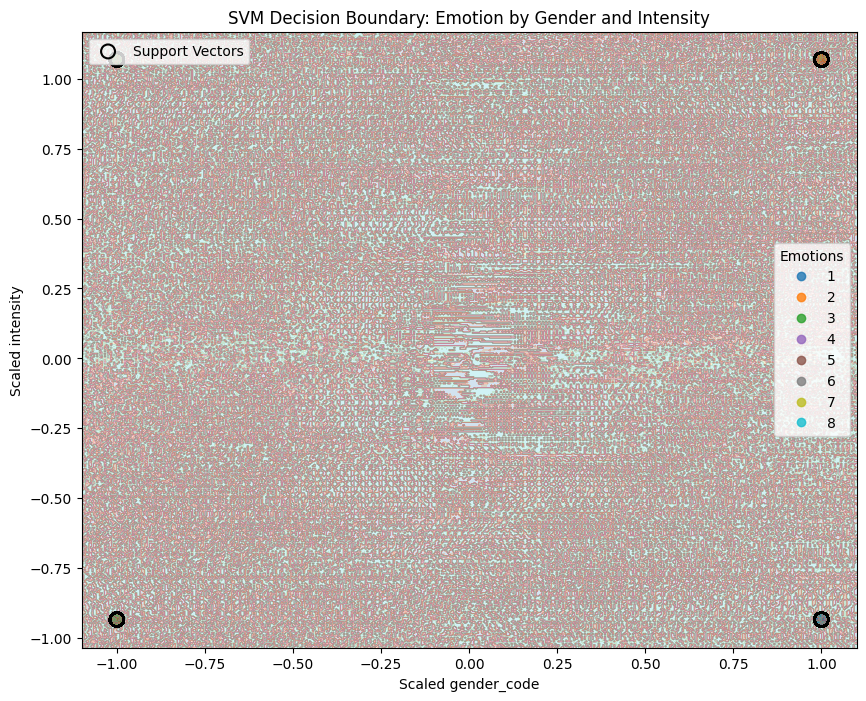

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler

# --- 1. Load your data ---
# df = pd.read_csv("your_data.csv")  # if not already loaded

# --- 2. Prepare Features (X) and Target (y) ---
X = df[['gender_code', 'intensity']].values
y = df['emotion_code'].values

# Optional but recommended: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Create and Train the SVM Model ---
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')  # one-vs-rest for multi-class
clf.fit(X_scaled, y)

# --- 4. Visualization ---
print("Plotting SVM decision boundary...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the data points
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=50, cmap='tab10', alpha=0.8)
ax.set_title('SVM Decision Boundary: Emotion by Gender and Intensity')
ax.set_xlabel('Scaled gender_code')
ax.set_ylabel('Scaled intensity')

# --- Create mesh grid for decision regions ---
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 500)
yy = np.linspace(ylim[0], ylim[1], 500)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# --- Predict class for each point in grid ---
Z = clf.predict(xy).reshape(XX.shape)

# --- Plot the class regions ---
ax.contourf(XX, YY, Z, alpha=0.2, cmap='tab10')

# --- Highlight support vectors ---
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')

# Add legend
legend_classes = ax.legend(*scatter.legend_elements(), title="Emotions")
ax.add_artist(legend_classes)
plt.legend(loc='upper left')

plt.show()

Plotting SVM decision boundary...


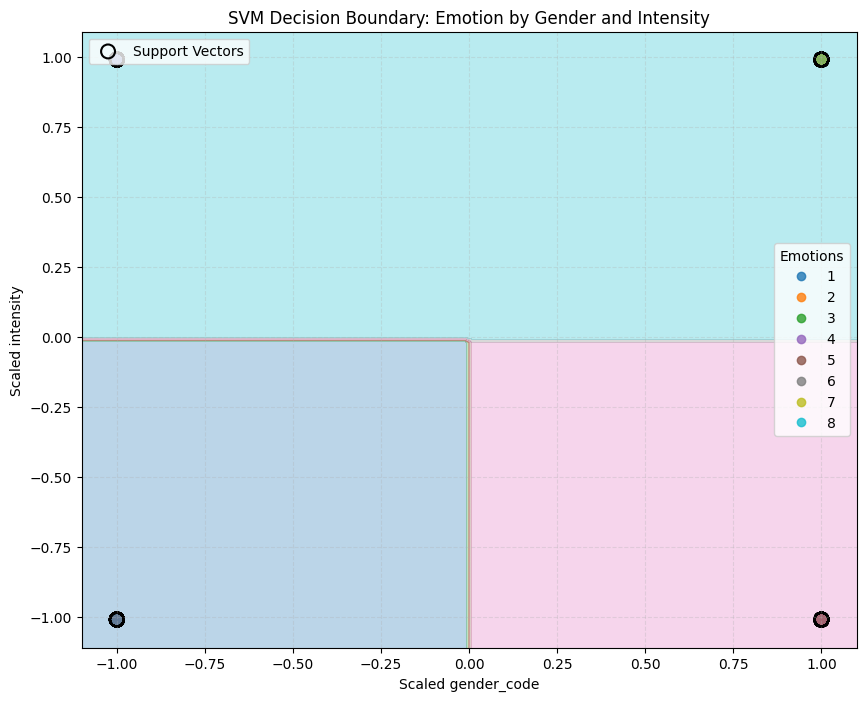

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# --- 1. Generate Synthetic Data (Emotion, Gender, Intensity) ---
# Simulate gender_code (0, 1) and intensity (1–2) with multi-class emotion
np.random.seed(42)
n_samples = 200
gender_code = np.random.choice([0, 1], size=n_samples)
intensity = np.random.choice([1, 2], size=n_samples)
emotion_code = np.random.choice([1, 2, 3, 4, 5, 6, 7, 8], size=n_samples)

# Combine into feature matrix
X = np.column_stack((gender_code, intensity))
y = emotion_code

# --- 2. Scale the Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Train the SVM Model ---
clf = svm.SVC(kernel='linear', decision_function_shape='ovr')
clf.fit(X_scaled, y)

# --- 4. Plotting ---
print("Plotting SVM decision boundary...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the training data points
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='tab10', s=50, alpha=0.8)
ax.set_title('SVM Decision Boundary: Emotion by Gender and Intensity')
ax.set_xlabel('Scaled gender_code')
ax.set_ylabel('Scaled intensity')

# --- 5. Create Mesh Grid for Decision Boundary ---
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Predict emotion class for each grid point
Z = clf.predict(xy).reshape(XX.shape)

# --- 6. Plot Decision Regions ---
ax.contourf(XX, YY, Z, alpha=0.3, cmap='tab10')

# Highlight support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=100, facecolors='none', edgecolors='black', linewidth=1.5, label='Support Vectors')

# Legend for classes
legend1 = ax.legend(*scatter.legend_elements(), title="Emotions")
ax.add_artist(legend1)
plt.legend(loc='upper left')

# Optional: Add grid for better clarity
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()

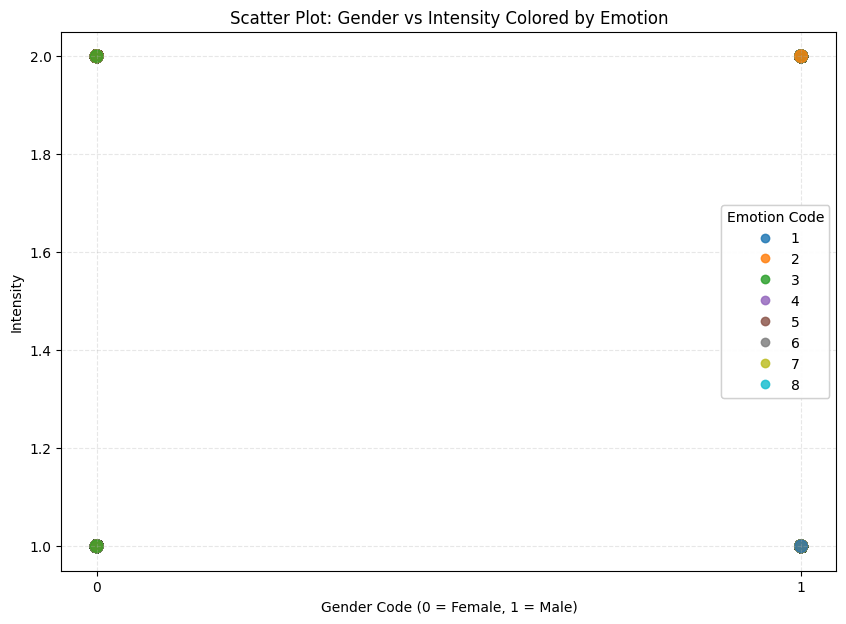

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['gender_code'],
    df['intensity'],
    c=df['emotion_code'],
    cmap='tab10',
    s=80,
    alpha=0.8
)

plt.title("Scatter Plot: Gender vs Intensity Colored by Emotion")
plt.xlabel("Gender Code (0 = Female, 1 = Male)")
plt.ylabel("Intensity")
plt.xticks([0, 1])

# Add color legend
legend1 = plt.legend(*scatter.legend_elements(), title="Emotion Code")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [ ]:
%

In [ ]:
!pip install librosa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 712.2 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 559.4 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.2/160.2 kB 2.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.6/64.6 kB 579.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 766.7 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 666.8 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 240.3 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.6/178.6 kB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 2.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━

In [ ]:
import librosa
import numpy as np

def extract_mfcc_features(audio_path, sr=22050, n_mfcc=13):
    y, sr = librosa.load(audio_path, sr=sr)
    
    # Base MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Delta (MFCC-T)
    mfcc_delta = librosa.feature.delta(mfcc)
    
    # Delta-Delta (optional)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    
    # Combine (MFCC + Δ + ΔΔ)
    combined = np.vstack((mfcc, mfcc_delta, mfcc_delta2))  # shape: (3*n_mfcc, T)
    
    return combined.T  # shape: (T, features)

In [ ]:
def extract_time_domain_features(y):
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rms = np.mean(librosa.feature.rms(y))
    return np.array([zcr, rms])

In [ ]:
def build_feature_vector(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfcc_features = extract_mfcc_features(audio_path)  # shape: (T, 39)
    mfcc_mean = np.mean(mfcc_features, axis=0)
    mfcc_std = np.std(mfcc_features, axis=0)
    
    time_features = extract_time_domain_features(y)
    
    # Combine all
    final_vector = np.concatenate([mfcc_mean, mfcc_std, time_features])
    return final_vector  # shape: (39*2 + 2 = 80)

In [ ]:
%pip install tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 637.0 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:


import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

In [ ]:
# 📁 Collect all .wav files from nested folders
def get_all_audio_files(path):
    audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.wav'):
                full_path = os.path.join(root, file)
                audio_files.append(full_path)
    return audio_files

all_files = get_all_audio_files("Audio_Speech_Actors_01-24")
print(f"Found {len(all_files)} audio files.")

Found 1440 audio files.


In [ ]:
# 🎙️ Function to extract MFCC and MFCC-T features only
def extract_mfcc_and_delta(audio_path, n_mfcc=13):
    y, sr = librosa.load(audio_path, sr=22050)
    
    # Base MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Delta MFCC (MFCC-T)
    delta = librosa.feature.delta(mfcc)
    
    # Take mean of each coefficient over time axis
    mfcc_mean = np.mean(mfcc, axis=1)
    delta_mean = np.mean(delta, axis=1)
    
    # Combine both
    combined = np.concatenate([mfcc_mean, delta_mean])
    return combined

In [ ]:
# 🔁 Process all files and build feature table
features = []
file_names = []

for file in tqdm(all_files):
    try:
        feature_vector = extract_mfcc_and_delta(file)
        features.append(feature_vector)
        file_names.append(os.path.basename(file))  # or full path
    except Exception as e:
        print(f"Error in {file}: {e}")

100%|██████████| 1440/1440 [00:11<00:00, 125.44it/s]


In [ ]:
# 🧾 Create a DataFrame
n_mfcc = 13
columns = [f'mfcc_{i}' for i in range(n_mfcc)] + [f'mfcct_{i}' for i in range(n_mfcc)]

df = pd.DataFrame(features, columns=columns)
df['file'] = file_names

# 🔽 Save to a CSV file (replace 'your_file.csv' with the one you want to add to)
save_path = "your_file.csv"  # Change this to your desired file name
df.to_csv(save_path, index=False)
print(f"✅ Saved extracted features to: {save_path}")

✅ Saved extracted features to: your_file.csv


In [ ]:
import pandas as pd
import os

# Load your CSV
df = pd.read_csv("ravdess_full_metadata.csv")  # replace with your actual filename

# Cut front path and keep only filename
df['id'] = df['file_path'].apply(os.path.basename)

# (Optional) Save the updated DataFrame
df.to_csv("base_data.csv", index=False)

print(df.head())

                                           file_path  modality  vocal_channel  \
0  /Users/upendrasuryajonnalagadda/mindseye/Audio...         3              1   
1  /Users/upendrasuryajonnalagadda/mindseye/Audio...         3              1   
2  /Users/upendrasuryajonnalagadda/mindseye/Audio...         3              1   
3  /Users/upendrasuryajonnalagadda/mindseye/Audio...         3              1   
4  /Users/upendrasuryajonnalagadda/mindseye/Audio...         3              1   

   emotion  emotion_code  intensity  statement  repetition  actor  gender  \
0    angry             5          1          2           1     16  female   
1  fearful             6          1          2           2     16  female   
2  fearful             6          2          1           2     16  female   
3    angry             5          2          1           1     16  female   
4  disgust             7          1          1           1     16  female   

                         id  
0  03-01-05-01-02-01

In [16]:
df1=pd.read_csv("base_data.csv")
df2=pd.read_csv("your_file.csv")

df=pd.merge(df1,df2,left_on="id",right_on="file",how="inner")

df.to_csv("audio_main.csv")